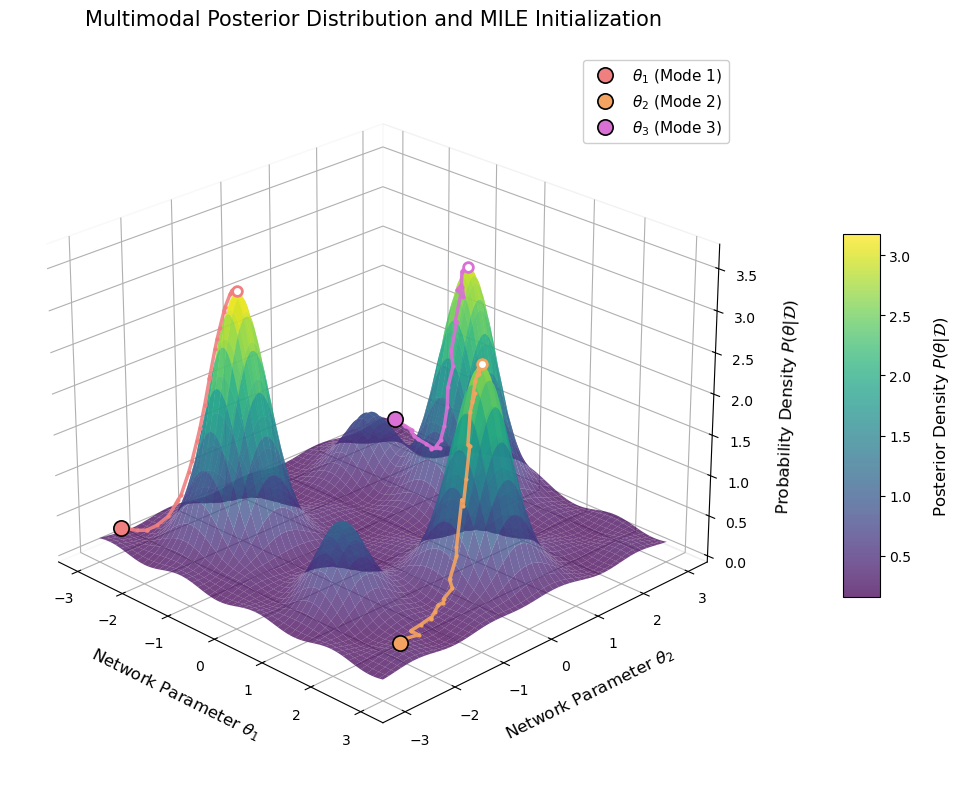

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def posterior_density(x, y):
    mode1 = 3.0 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 0.4)
    mode2 = 2.5 * np.exp(-((x - 1.8)**2 + (y - 0.2)**2) / 0.4)
    mode3 = 2.8 * np.exp(-((x + 0.2)**2 + (y - 2.0)**2) / 0.4)
    
    minor_mode1 = 1.0 * np.exp(-((x - 1.0)**2 + (y + 1.8)**2) / 0.3)
    minor_mode2 = 0.8 * np.exp(-((x + 1.8)**2 + (y - 1.5)**2) / 0.3)
    
    base_density = 0.2 + 0.05 * np.sin(4 * x) * np.cos(4 * y)
    
    return mode1 + mode2 + mode3 + minor_mode1 + minor_mode2 + base_density

x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = posterior_density(X, Y)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.75, antialiased=True, edgecolor='none', zorder=1)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r'Posterior Density $P(\theta|\mathcal{D})$', rotation=90, labelpad=15, fontsize=12)

initializations = [
    (-2.8, -2.8, -1.5, -1.5, 'lightcoral', r'$\theta_1$ (Mode 1)'),   
    (2.8, -2.5, 1.8, 0.2, 'sandybrown', r'$\theta_2$ (Mode 2)'),     
    (-2.5, 2.8, -0.2, 2.0, 'orchid', r'$\theta_3$ (Mode 3)')         
]

np.random.seed(42)

for x_start, y_start, x_end, y_end, color, label in initializations:
    steps = 40 
    
    t = np.linspace(0, 1, steps)
    curve = 1 - (1 - t)**3 
    
    noise_envelope = 0.06 * (1 - t) 
    
    x_path = x_start + (x_end - x_start) * curve + np.random.normal(0, 1, steps) * noise_envelope
    y_path = y_start + (y_end - y_start) * curve + np.random.normal(0, 1, steps) * noise_envelope
    
    # DER FIX: Dynamischer Z-Offset!
    # Startet bei 0.15 (verhindert Clipping im Tal) und sinkt linear auf 0.02 ab.
    # Dadurch landet die Endkugel satt und physikalisch korrekt auf der Spitze.
    dynamic_z_offset = 0.15 * (1 - t) + 0.02 * t 
    
    z_path = posterior_density(x_path, y_path) + dynamic_z_offset
    
    ax.plot(x_path, y_path, z_path, color=color, linewidth=2.5, marker='.', markersize=4, alpha=0.9, zorder=10)
    
    # Startpunkt (Hat automatisch den Z-Offset von 0.15)
    ax.plot([x_path[0]], [y_path[0]], [z_path[0]], 
            color=color, marker='o', markersize=11, markeredgecolor='black', markeredgewidth=1.2, 
            linestyle='none', label=label, zorder=20)
    
    # Zielpunkt (Hat automatisch den Z-Offset von 0.02 -> sitzt perfekt auf dem Gipfel)
    ax.plot([x_path[-1]], [y_path[-1]], [z_path[-1]], 
            color='white', marker='o', markersize=7, markeredgecolor=color, markeredgewidth=2, 
            linestyle='none', zorder=20)

ax.set_title("Multimodal Posterior Distribution and MILE Initialization", fontsize=15, pad=20)
ax.set_xlabel(r"Network Parameter $\theta_1$", labelpad=10, fontsize=12)
ax.set_ylabel(r"Network Parameter $\theta_2$", labelpad=10, fontsize=12)
ax.set_zlabel(r"Probability Density $P(\theta|\mathcal{D})$", labelpad=10, fontsize=12)

ax.set_zlim(0, np.max(Z) + 0.5)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.view_init(elev=25, azim=-45)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
# plt.savefig("mile_posterior_distribution.pdf", dpi=300, bbox_inches='tight')
plt.savefig("posterior_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

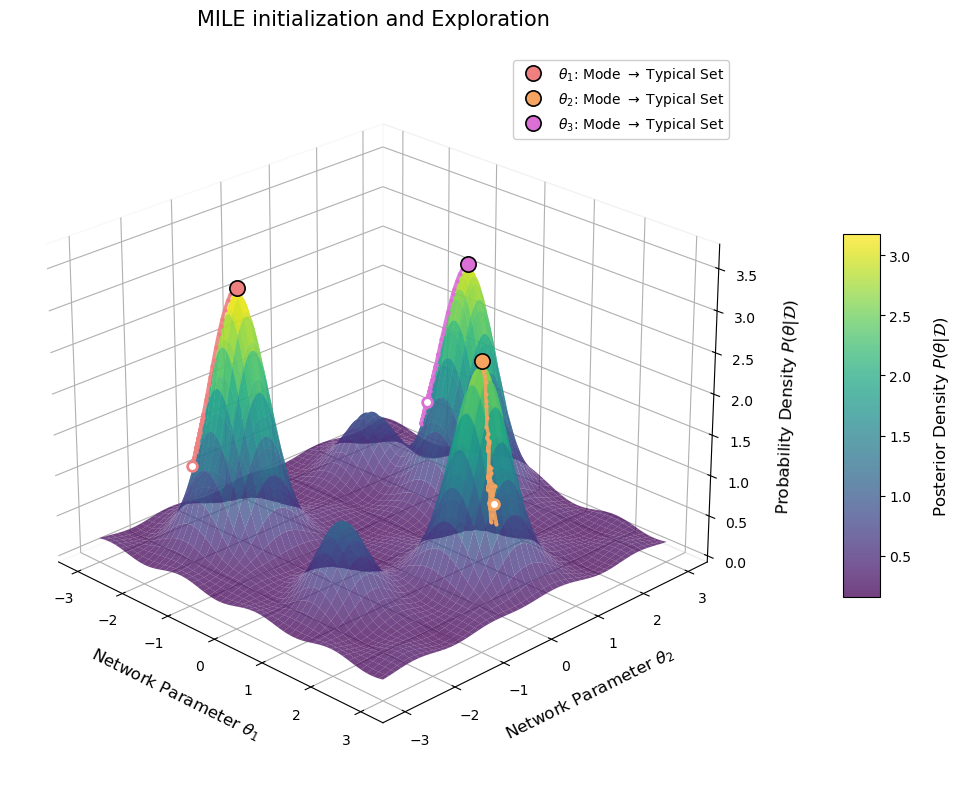

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def posterior_density(x, y):
    mode1 = 3.0 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 0.4)
    mode2 = 2.5 * np.exp(-((x - 1.8)**2 + (y - 0.2)**2) / 0.4)
    mode3 = 2.8 * np.exp(-((x + 0.2)**2 + (y - 2.0)**2) / 0.4)
    
    minor_mode1 = 1.0 * np.exp(-((x - 1.0)**2 + (y + 1.8)**2) / 0.3)
    minor_mode2 = 0.8 * np.exp(-((x + 1.8)**2 + (y - 1.5)**2) / 0.3)
    
    base_density = 0.2 + 0.05 * np.sin(4 * x) * np.cos(4 * y)
    
    return mode1 + mode2 + mode3 + minor_mode1 + minor_mode2 + base_density

x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = posterior_density(X, Y)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.75, antialiased=True, edgecolor='none', zorder=1)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r'Posterior Density $P(\theta|\mathcal{D})$', rotation=90, labelpad=15, fontsize=12)

# Chains now START exactly at the mode (MAP optimum) and move a SHORT distance
# away into the surrounding typical set -- not toward a different mode.
initializations = [
    (-1.5, -1.5, -1.95, -1.95, 'lightcoral', r'$\theta_1$: Mode $\to$ Typical Set'),
    (1.8, 0.2, 2.3, -0.1, 'sandybrown', r'$\theta_2$: Mode $\to$ Typical Set'),
    (-0.2, 2.0, -0.65, 1.6, 'orchid', r'$\theta_3$: Mode $\to$ Typical Set')
]

np.random.seed(42)

for x_start, y_start, x_end, y_end, color, label in initializations:
    steps = 40

    t = np.linspace(0, 1, steps)
    curve = 1 - (1 - t)**3

    # Noise grows as the chain leaves the deterministic mode and enters
    # the stochastic warmup exploration of the typical set.
    noise_envelope = 0.05 * t

    x_path = x_start + (x_end - x_start) * curve + np.random.normal(0, 1, steps) * noise_envelope
    y_path = y_start + (y_end - y_start) * curve + np.random.normal(0, 1, steps) * noise_envelope

    # Both start and end lie near the surface (no deep valley to clip out of),
    # so a small constant offset keeps markers visible without distortion.
    z_offset = 0.06
    z_path = posterior_density(x_path, y_path) + z_offset

    ax.plot(x_path, y_path, z_path, color=color, linewidth=2.5, marker='.', markersize=4, alpha=0.9, zorder=10)

    # Start point: exactly at the mode (filled marker)
    ax.plot([x_path[0]], [y_path[0]], [z_path[0]],
            color=color, marker='o', markersize=11, markeredgecolor='black', markeredgewidth=1.2,
            linestyle='none', label=label, zorder=20)

    # End point: displaced into the typical set (hollow marker)
    ax.plot([x_path[-1]], [y_path[-1]], [z_path[-1]],
            color='white', marker='o', markersize=7, markeredgecolor=color, markeredgewidth=2,
            linestyle='none', zorder=20)

ax.set_title("MILE initialization and Exploration", fontsize=15, pad=20)
ax.set_xlabel(r"Network Parameter $\theta_1$", labelpad=10, fontsize=12)
ax.set_ylabel(r"Network Parameter $\theta_2$", labelpad=10, fontsize=12)
ax.set_zlabel(r"Probability Density $P(\theta|\mathcal{D})$", labelpad=10, fontsize=12)

ax.set_zlim(0, np.max(Z) + 0.5)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.view_init(elev=25, azim=-45)
ax.legend(fontsize=10, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig("posterior_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

#### Create Plots for Dataset vs Epochs

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(ROOT)
from src.Orchestration.ablation_metrics import (
    build_ablation_delta_series,
    format_metric_delta_assignments,
)


/Users/kingmopser/BachelorThesis/BachelorsThesisCode


In [ ]:

series = build_ablation_delta_series(
    visuals_root=ROOT / "src" / "visuals",
    baseline_table_map={
        "fiat": "fiat_500",
        "wine": "wine_quality",
        "healthcare": "healthcare_insurance",
        "miami": "miami_housing",
    },
    dataset_name_map={
        "fiat": "fiat500",
        "wine": "winequality",
        "healthcare": "healthinsurance",
        "miami": "miami_housing",
    },
    round_digits=4,
)

print(format_metric_delta_assignments(series, digits=4))

In [5]:
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}

metrics = {
    "RMSE": data_rmse,
    "NLL": data_nll,
    "Winkler": data_winkler,
    "WinklerCoverage": data_winklercoverage,
}
latex = []
latex.append(r"\begin{tabular}{l r r r r r}")
latex.append(r"\toprule")
latex.append(r"Dataset & Epoch & RMSE & NLL & Winkler & WinklerCoverage \\")
latex.append(r"\midrule")

epochs = [400, 800, 1200]

for dataset in data_rmse.keys():
    dataset_name = dataset.replace("_", r"\_")
    for i, epoch in enumerate(epochs):
        latex.append(
            f"{dataset_name} & "
            f"{epoch} & "
            f"{data_rmse[dataset][i]:.4f} & "
            f"{data_nll[dataset][i]:.4f} & "
            f"{data_winkler[dataset][i]:.4f} & "
            f"{data_winklercoverage[dataset][i]:.4f} \\\\"
        )

latex.append(r"\bottomrule")

latex_table = "\n".join(latex)

with open("epoch_results_table.tex", "w") as f:
    f.write(latex_table)

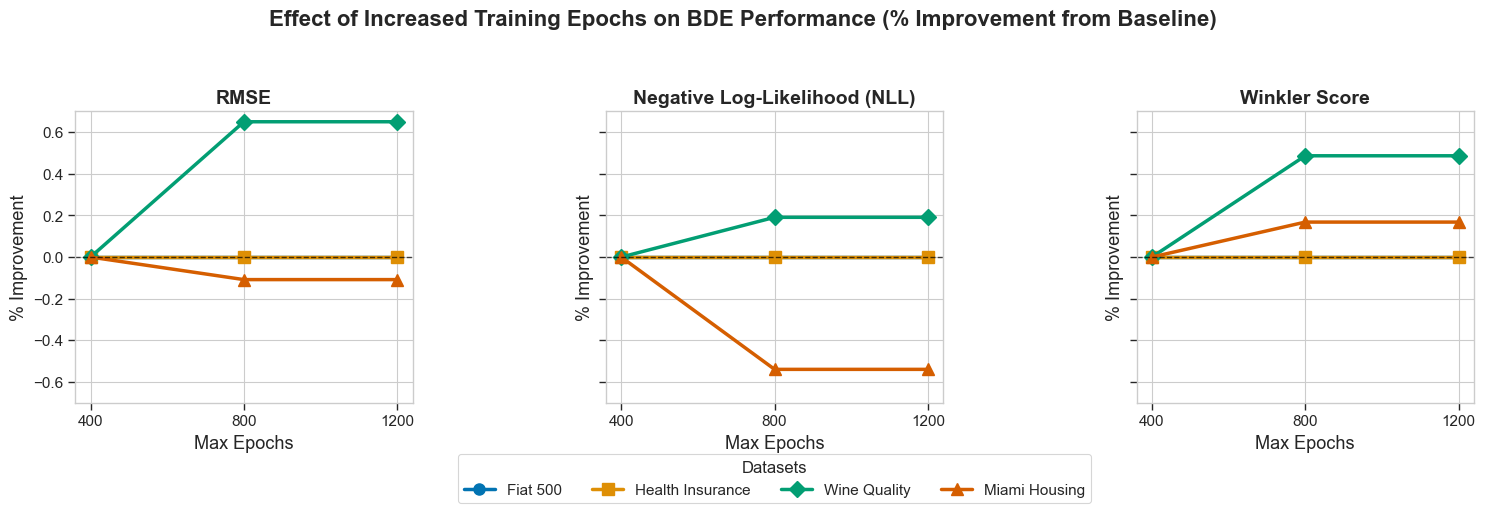

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. Setup and Aesthetic Configuration
# ==========================================
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)

datasets = ["fiat500", "healthcare_insurance", "wine_quality", "miami_housing"]
epochs = ["400", "800", "1200"]

dataset_labels = {
    "fiat500": "Fiat 500",
    "healthcare_insurance": "Health Insurance",
    "wine_quality": "Wine Quality",
    "miami_housing": "Miami Housing",
}

palette = sns.color_palette("colorblind", 4)
dataset_colors = {
    "fiat500": palette[0],
    "healthcare_insurance": palette[1],
    "wine_quality": palette[2],
    "miami_housing": palette[3],
}

dataset_markers = {
    "fiat500": "o",
    "healthcare_insurance": "s",
    "wine_quality": "D",
    "miami_housing": "^",
}

# ==========================================
# 2. Data
# ==========================================
data_rmse = {
    "fiat500": [0, 0, 0],
    "healthcare_insurance": [0, 0, 0],
    "miami_housing": [0, 0.1083, 0.1083],
    "wine_quality": [0, -0.6502, -0.6502],
}

data_nll = {
    "fiat500": [0, 0, 0],
    "healthcare_insurance": [0, 0, 0],
    "miami_housing": [0, 0.5396, 0.5396],
    "wine_quality": [0, -0.191, -0.191],
}

data_winkler = {
    "fiat500": [0, 0, 0],
    "healthcare_insurance": [0, 0, 0],
    "miami_housing": [0, -0.1681, -0.1681],
    "wine_quality": [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    "fiat500": [0, 0, 0],
    "healthcare_insurance": [0, 0, 0],
    "miami_housing": [0, -0.0218, -0.0218],
    "wine_quality": [0, -0.0219, -0.0219],
}

# ==========================================
# 3. Plotting
# ==========================================
def to_improvement(delta_dict):
    return {
        dataset: [-value for value in values]
        for dataset, values in delta_dict.items()
    }

plot_rmse = to_improvement(data_rmse)
plot_nll = to_improvement(data_nll)
plot_winkler = to_improvement(data_winkler)

all_values = [
    value
    for plot_data in (plot_rmse, plot_nll, plot_winkler)
    for values in plot_data.values()
    for value in values
]
y_limit = max(abs(min(all_values)), abs(max(all_values))) + 0.05

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    "Effect of Increased Training Epochs on BDE Performance (% Improvement from Baseline)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

metrics = [
    ("RMSE", plot_rmse, axes[0]),
    ("Negative Log-Likelihood (NLL)", plot_nll, axes[1]),
    ("Winkler Score", plot_winkler, axes[2]),
]

for metric_name, data_dict, ax in metrics:
    for dataset in datasets:
        ax.plot(
            epochs,
            data_dict[dataset],
            marker=dataset_markers[dataset],
            linewidth=2.5,
            markersize=8,
            label=dataset_labels[dataset],
            color=dataset_colors[dataset],
        )

    ax.set_title(metric_name, fontsize=14, fontweight="bold")
    ax.set_xlabel("Max Epochs", fontsize=13)
    ax.set_ylabel("% Improvement", fontsize=13)
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylim(-y_limit, y_limit)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

axes[1].legend(
    title="Datasets",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=True,
    fancybox=True,
    shadow=False,
    fontsize=11,
    title_fontsize=12,
)

plt.tight_layout()
plt.savefig("epoch_ablation_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

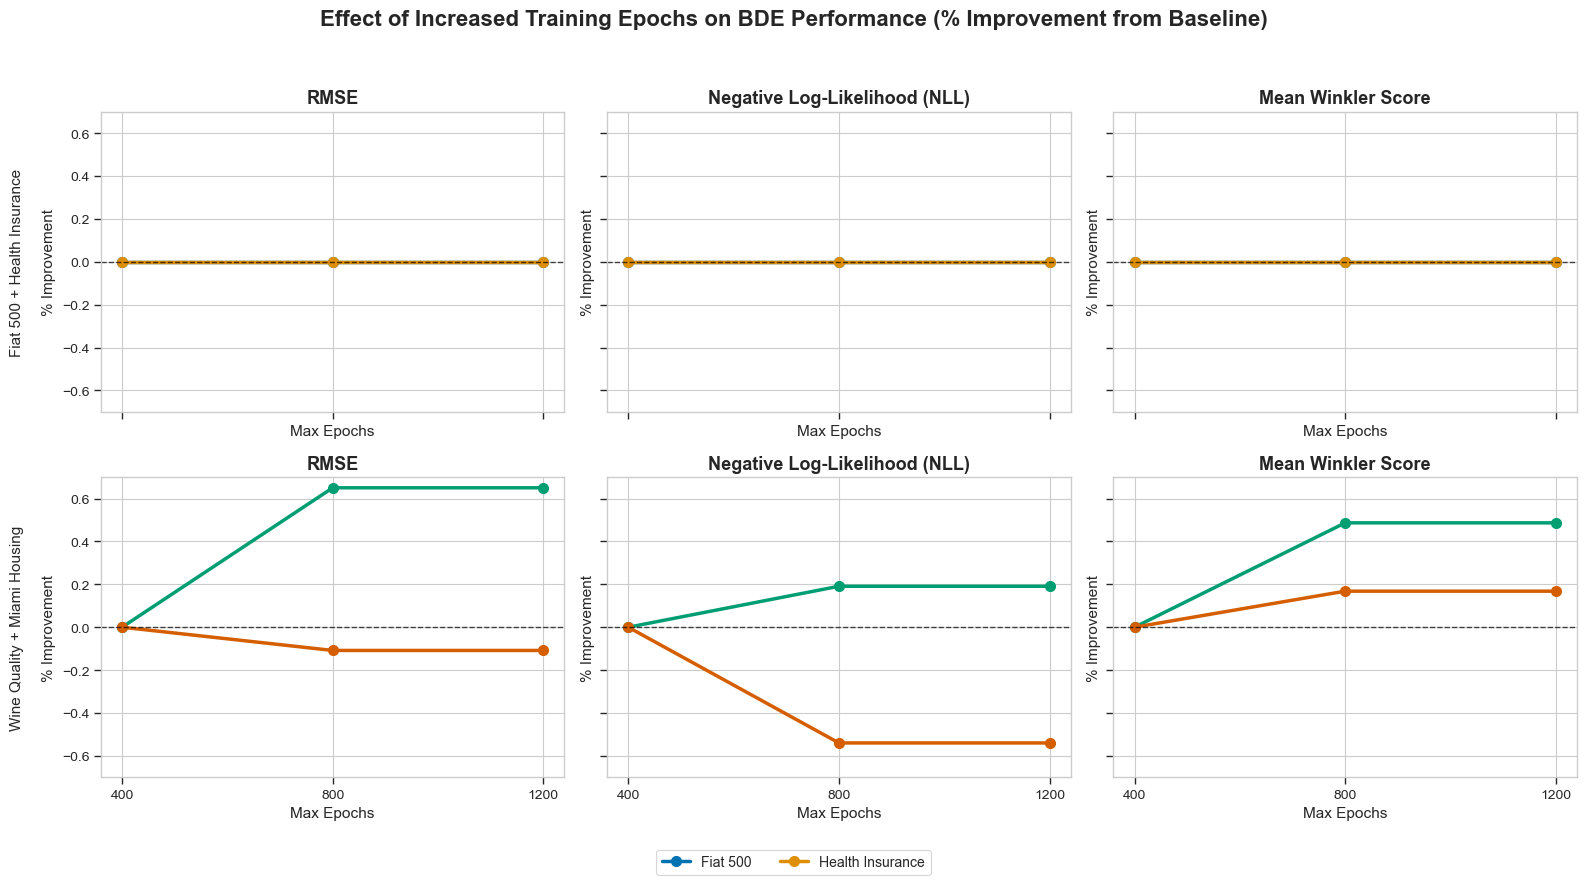

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.15)

epochs = ["400", "800", "1200"]
data_rmse = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.1083, 0.1083],
    'wine_quality': [0, -0.6502, -0.6502],
}

data_nll = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, 0.5396, 0.5396],
    'wine_quality': [0, -0.191, -0.191],
}

data_winkler = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.1681, -0.1681],
    'wine_quality': [0, -0.4867, -0.4867],
}

data_winklercoverage = {
    'fiat500': [0, 0, 0],
    'healthcare_insurance': [0, 0, 0],
    'miami_housing': [0, -0.0218, -0.0218],
    'wine_quality': [0, -0.0219, -0.0219],
}

dataset_labels = {
    "fiat500": "Fiat 500",
    "healthcare_insurance": "Health Insurance",
    "wine_quality": "Wine Quality",
    "miami_housing": "Miami Housing",
}

dataset_groups = [
    ("Fiat 500 + Health Insurance", ["fiat500", "healthcare_insurance"]),
    ("Wine Quality + Miami Housing", ["wine_quality", "miami_housing"]),
]

def to_improvement(delta_dict):
    return {
        dataset: [-value for value in values]
        for dataset, values in delta_dict.items()
    }

plot_rmse = to_improvement(data_rmse)
plot_nll = to_improvement(data_nll)
plot_winkler = to_improvement(data_winkler)

metric_specs = [
    ("RMSE", plot_rmse),
    ("Negative Log-Likelihood (NLL)", plot_nll),
    ("Mean Winkler Score", plot_winkler),
]

palette = sns.color_palette("colorblind", 4)
dataset_colors = {
    "fiat500": palette[0],
    "healthcare_insurance": palette[1],
    "wine_quality": palette[2],
    "miami_housing": palette[3],
}

all_values = [
    value
    for _, metric_data in metric_specs
    for values in metric_data.values()
    for value in values
]
y_limit = max(abs(min(all_values)), abs(max(all_values))) + 0.05

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
fig.suptitle(
    "Effect of Increased Training Epochs on BDE Performance (% Improvement from Baseline)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

for row_idx, (group_title, datasets) in enumerate(dataset_groups):
    for col_idx, (metric_name, metric_data) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]

        for dataset in datasets:
            ax.plot(
                epochs,
                metric_data[dataset],
                marker="o",
                linewidth=2.5,
                markersize=7,
                label=dataset_labels[dataset],
                color=dataset_colors[dataset],
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.set_title(metric_name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Max Epochs")

        if col_idx == 0:
            ax.set_ylabel(f"{group_title}\n\n% Improvement", fontsize=11)
        else:
            ax.set_ylabel("% Improvement", fontsize=11)

        ax.set_ylim(-y_limit, y_limit)
        ax.tick_params(axis="both", labelsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("epoch_ablation_plot_6panel.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### This is for the Dataset Complextiy vs Hidden Layers
